In [47]:
import json
import random
import csv
import tensorflow as tf
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

In [48]:
all_data = json.load(open('./raw_data.json', 'r'))

In [49]:
len(all_data)

820

In [54]:
data = []
check_double = set()
for entry in all_data:
    if entry['task'] == 'classify' and entry['ab'] == 'B':# and entry.get('version') != 2:
        unique_key = entry['workerId'] + entry['taskId']
        if unique_key in check_double:
            continue
        check_double.add(unique_key)
        data.extend(dict(item, worker=entry['workerId']) for item in entry['items'])

In [55]:
faces = sorted(set(row['file'] for row in data))

In [56]:
len(data), len(faces)

(8780, 20)

0.08132118451025057


(array([8.655e+03, 8.900e+01, 1.500e+01, 9.000e+00, 3.000e+00, 2.000e+00,
        4.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([ 1. ,  5.9, 10.8, 15.7, 20.6, 25.5, 30.4, 35.3, 40.2, 45.1, 50. ]),
 <BarContainer object of 10 artists>)

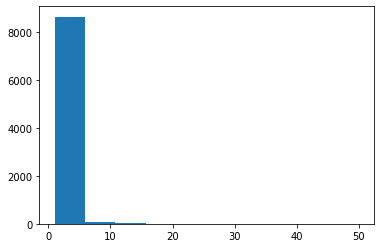

In [179]:
print(np.mean([row['sample']>1 for row in data]))
plt.hist([row['sample'] for row in data])

In [57]:
def get_vec(state):
    a = state['arousal']/100
    e = (state['expression']/50-1)/2
    a1 = round(min(1, max(0, a - e)), 2)
    a2 = round(min(1, max(0, a + e)), 2)
    return np.array([
        state['valence'] / 100.0,
        a1, a2,
        state['potency'] / 100.0,
        state['contempt'] / 100.0
    ])

def get_data(data, face):
    return [
        {
            "choices": [get_vec(choice) for choice in row['choices']],
            "selected": get_vec(row['choices'][row['selected']]),
        }
        for row in data if row['file'] == face
    ]

In [62]:
def get_mats(DATA):
    numer = np.zeros((5, 1,  len(DATA)))
    denom = np.zeros((5, 15, len(DATA)))
    for j in range(len(DATA)):
        numer[:, 0, j] = DATA[j]['selected']
        for i in range(15):
            denom[:, i, j] = DATA[j]['choices'][i]
    return tf.constant(numer), tf.constant(denom)

def loss(numer, denom, mu, sigma):
    s = tf.exp(sigma)
    #mu = 1/(1+tf.exp(-mu))
    loss1 = tf.math.exp(- tf.reduce_sum((mu - numer)**2 * s, axis= 0))
    loss2 = tf.reduce_sum(
            tf.math.exp(- tf.reduce_sum((mu - denom)**2 * s, axis=0)), axis=0)
    loss = -tf.reduce_sum(tf.math.log(tf.squeeze(loss1)) - tf.math.log(loss2))
    return loss

In [63]:
def fit_model(data):
    RESULT = np.zeros((len(faces), 2, 5))
    for f in range(len(faces)):
        face = faces[f]
        mu = tf.Variable(np.zeros((5,1,1)))
        sigma = tf.Variable(np.zeros((5,1,1)))
        DATA= get_data(data, face)
        opt = tf.keras.optimizers.Adam(learning_rate = 0.01)
        with tf.GradientTape(persistent=True) as tape:
            numer, denom = get_mats(DATA)
            L = lambda: loss(numer, denom, mu, sigma)
        print(f"{face=}: ", end="")
        for epoch in range(20):
            print(f".", end="")
            mu_old = mu.numpy()
            for iter in range(300):
                opt.minimize(L, [mu, sigma], tape=tape)
                mu.assign(tf.math.maximum(mu, 0.0))
                mu.assign(tf.math.minimum(mu, 1.0))
            dist = np.max(np.abs(mu_old - mu.numpy()))
            if dist < 0.0001:
                break
        print()
        RESULT[f,:, :] = [ np.squeeze(mu.numpy()), np.exp(-0.5 * np.squeeze(sigma.numpy())) ]
    return RESULT

In [64]:
def write_result(RESULT, filename):
    RESULT = np.round(RESULT,4)
    with open(f'gen/{filename}', 'w') as out:
        json.dump({
            faces[i] : {
                "x_opt" : RESULT[i][0].tolist(),
                "x_std" : RESULT[i][1].tolist(),
            }
            for i in range(len(faces))
        }, out, indent=2)

In [65]:
RESULT = fit_model(data)
write_result(RESULT, 'resultB.json')

face='img_align_celeba/000838.jpg': ..............
face='img_align_celeba/012499.jpg': ..........
face='img_align_celeba/024857.jpg': .......
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ......
face='img_align_celeba/090689.jpg': ......
face='img_align_celeba/092099.jpg': .........
face='img_align_celeba/093560.jpg': .....
face='img_align_celeba/106786.jpg': ....
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ...
face='img_align_celeba/153630.jpg': ......
face='img_align_celeba/167840.jpg': .....
face='img_align_celeba/168485.jpg': ......
face='img_align_celeba/173110.jpg': ....
face='img_align_celeba/181029.jpg': ..........
face='img_align_celeba/195696.jpg': .......
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ......
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': .....
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ....


In [ ]:
plt.bar(x=['v','a1','a2','p','c'], height=np.mean(RESULT[:,1,:], axis=0))

# Bayesian decoding

In [166]:
workers = np.random.permutation(sorted(set(row['worker'] for row in data)))
selected = { workers[i] : i < len(workers)//2 for i in range(len(workers)) } 

In [167]:
data1 = [row for row in data if selected[row['worker']]]
data2 = [row for row in data if not selected[row['worker']]]
Result1 = fit_model(data1)
Result2 = fit_model(data2)

face='img_align_celeba/000838.jpg': .........
face='img_align_celeba/012499.jpg': .....
face='img_align_celeba/024857.jpg': ......
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ......
face='img_align_celeba/090689.jpg': .......
face='img_align_celeba/092099.jpg': ...........
face='img_align_celeba/093560.jpg': .........
face='img_align_celeba/106786.jpg': ......
face='img_align_celeba/117396.jpg': ....
face='img_align_celeba/128198.jpg': ...
face='img_align_celeba/153630.jpg': .......
face='img_align_celeba/167840.jpg': .....
face='img_align_celeba/168485.jpg': ......
face='img_align_celeba/173110.jpg': ....
face='img_align_celeba/181029.jpg': .........
face='img_align_celeba/195696.jpg': .....
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ....
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': .....
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': .....
face='img_align_celeba/000838.jpg': ..................
face='img_align_celeba/012499.jpg': ......
face='im

In [160]:
write_result(Result1, 'resultB1.json')
write_result(Result2, 'resultB2.json')

In [168]:
Z = np.array([
        np.prod([scipy.stats.norm.cdf(1, Result2[i][0][j], Result2[i][1][j])  - 
                 scipy.stats.norm.cdf(0, Result2[i][0][j], Result2[i][1][j]) for j in range(Result1.shape[2])])
        for i in range(Result2.shape[0])
    ])

In [169]:
i= 0
N = 5000
p = np.ones(N)
for j in range(Result1.shape[2]):
    p *= scipy.stats.norm.pdf(np.random.random(N), Result2[i][0][j], Result2[i][1][j])
np.mean(p)/Z[i]

0.9988717048824635

In [170]:
total = 0
successes = 0
y = 5
for i in range(len(faces)):
    mu = Result1[i, 0]
    p0 = np.prod(scipy.stats.norm.pdf(mu, Result2[i, 0], Result2[i, 1])) / Z[i]
    ti = 0
    si = 0
    for j in range(40):
        others = list(range(0,i)) + list(range(i+1,len(faces)))
        decoys = np.random.choice(others, y, replace=False)
        ps = [ np.prod(scipy.stats.norm.pdf(mu, Result2[k, 0], Result2[k, 1])) / Z[k] for k in decoys]
        ti += 1
        si += p0 > np.max(ps)
    print(f"{i+1:2d} {faces[i]:41s}: {100 * si/ti:6.2f}")
    total += ti
    successes += si

 1 img_align_celeba/000838.jpg              : 100.00
 2 img_align_celeba/012499.jpg              : 100.00
 3 img_align_celeba/024857.jpg              : 100.00
 4 img_align_celeba/029376.jpg              : 100.00
 5 img_align_celeba/036568.jpg              : 100.00
 6 img_align_celeba/090689.jpg              :  15.00
 7 img_align_celeba/092099.jpg              : 100.00
 8 img_align_celeba/093560.jpg              : 100.00
 9 img_align_celeba/106786.jpg              : 100.00
10 img_align_celeba/117396.jpg              : 100.00
11 img_align_celeba/128198.jpg              : 100.00
12 img_align_celeba/153630.jpg              :  55.00
13 img_align_celeba/167840.jpg              : 100.00
14 img_align_celeba/168485.jpg              : 100.00
15 img_align_celeba/173110.jpg              :  70.00
16 img_align_celeba/181029.jpg              :  47.50
17 img_align_celeba/195696.jpg              : 100.00
18 lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg :   2.50
19 lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg : 

In [171]:
print(f"{successes}/{total} = {100*successes/total:.2f}")
print(f"M={y/(total/successes-1):.2f}")

633/800 = 79.12
M=18.95
